# Predicción agregada de demanda eléctrica a 24 horas (24 modelos)

In [ ]:
from pathlib import Path
from datetime import date, timedelta
import hashlib, json, math, os, warnings

import sklearn
from sklearn.metrics import r2_score
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import joblib

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import requests
import holidays
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

Configuración:

In [ ]:
PROJECT_ROOT = Path()

PROCESSED_DIR = PROJECT_ROOT / "processed"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts_aggregate_24h"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

INPUT_CONSUMPTION = PROCESSED_DIR / "consumption_users_le10pct_imputed.parquet"
INPUT_QUALITY = PROCESSED_DIR / "quality_report.parquet"
WEATHER_PARQUET = PROCESSED_DIR / "bilbao_weather_hourly.parquet"
LOCAL_HOLIDAYS_CSV = PROCESSED_DIR / "bilbao_local_holidays.csv"

AGGREGATED_PARQUET = PROCESSED_DIR / "bilbao_ce_aggregate_hourly.parquet"
FEATURES_PARQUET = PROCESSED_DIR / "bilbao_ce_aggregate_features.parquet"

MAX_IMPUTED_PCT = 10.0

CONSUMPTION_TIMEZONE = "UTC"
LOCAL_TIMEZONE = "Europe/Madrid"

FORECAST_ORIGIN_LOCAL_HOUR = 23
FORECAST_HORIZON = 24

# Splits para train, val y test
TRAIN_END = pd.Timestamp("2021-06-01 00:00:00")
VAL_END = pd.Timestamp("2021-12-01 00:00:00")
TEST_END = pd.Timestamp("2022-06-01 00:00:00")

MIN_COMMUNITY_END = pd.Timestamp("2022-06-02 00:00:00")
MAX_TARGET_IMPUTED_USER_FRAC = 0.05

PARQUET_COMPRESSION = "zstd"
RANDOM_SEED = 42

# Comparación inicial de algoritmos usando horizontes representativos
PILOT_HORIZONS = [1, 6, 12, 18, 24]

FEATURE_IMPORTANCE_CUMULATIVE_THRESHOLD = 0.98
MIN_SELECTED_FEATURES = 20
MAX_SELECTED_FEATURES = 50

N_OPTUNA_TRIALS = 40

Cohorte de usuarios que comparten linea temporal:

In [3]:
quality = pd.read_parquet(INPUT_QUALITY)

quality["user_id"] = quality["user_id"].astype(str)
quality["start_date"] = pd.to_datetime(quality["start_date"])
quality["end_date"] = pd.to_datetime(quality["end_date"])

clean_users = quality.loc[
    quality["status"].eq("ok")
    & quality["imputed_pct"].le(MAX_IMPUTED_PCT)
].copy()

community_quality = clean_users.loc[
    clean_users["end_date"].ge(MIN_COMMUNITY_END)
].copy()

COMMUNITY_USERS = set(community_quality["user_id"].tolist())

COMMUNITY_START = community_quality["start_date"].max()
COMMUNITY_END = TEST_END + pd.Timedelta(days=2)

print(f"Usuarios limpios: {len(clean_users):,}")
print(f"Miembros de la CE fija: {len(COMMUNITY_USERS):,}")
print(f"Inicio común de la CE: {COMMUNITY_START}")
print(f"Fin utilizado: {COMMUNITY_END}")

display(
    community_quality[
        ["start_date", "end_date", "imputed_pct"]
    ].describe()
)

Usuarios limpios: 1,010
Miembros de la CE fija: 923
Inicio común de la CE: 2019-05-31 01:00:00
Fin utilizado: 2022-06-03 00:00:00


,start_date,end_date,imputed_pct
count,923,923,923.000000
mean,2017-10-19 10:52:47.063922,2022-06-04 20:37:03.185265,0.323862
min,2017-05-28 01:00:00,2022-06-02 00:00:00,0.013742
25%,2017-05-31 01:00:00,2022-06-05 00:00:00,0.023497
50%,2017-05-31 01:00:00,2022-06-05 00:00:00,0.129711
75%,2018-02-22 13:00:00,2022-06-05 00:00:00,0.248572
max,2019-05-31 01:00:00,2022-06-05 00:00:00,9.960404
std,NaN,NaN,0.873643


Construir la serie horaria agregada:

In [ ]:
def build_community_aggregate(
    input_parquet,
    community_users,
    start_time,
    end_time,
):
    full_index = pd.date_range(
        start=start_time,
        end=end_time,
        freq="h",
    )

    aggregate = pd.DataFrame(
        {
            "consumo_ce": np.zeros(len(full_index), dtype=np.float64),
            "n_users": np.zeros(len(full_index), dtype=np.int32),
            "n_imputed_users": np.zeros(len(full_index), dtype=np.int32),
        },
        index=full_index,
    )

    pf = pq.ParquetFile(input_parquet)

    processed_users = set()

    for rg in tqdm(
        range(pf.num_row_groups),
        desc="Agregando usuarios de la CE",
    ):
        group = pf.read_row_group(
            rg,
            columns=["user_id", "Fecha", "consumo", "imputed"],
        ).to_pandas()

        for user_id, user_df in group.groupby("user_id", sort=False):
            user_id = str(user_id)

            if user_id not in community_users:
                continue

            user_df["Fecha"] = pd.to_datetime(user_df["Fecha"])

            user_df = (
                user_df.loc[
                    user_df["Fecha"].between(
                        start_time,
                        end_time,
                        inclusive="both",
                    )
                ]
                .drop_duplicates("Fecha", keep="last")
                .set_index("Fecha")
                .reindex(full_index)
            )

            valid = user_df["consumo"].notna()

            aggregate.loc[valid, "consumo_ce"] += (
                user_df.loc[valid, "consumo"].to_numpy(dtype=float)
            )

            aggregate.loc[valid, "n_users"] += 1

            aggregate.loc[valid, "n_imputed_users"] += (
                user_df.loc[valid, "imputed"]
                .fillna(0)
                .to_numpy(dtype=np.int32)
            )

            processed_users.add(user_id)

    aggregate["imputed_user_frac"] = (
        aggregate["n_imputed_users"]
        / np.maximum(aggregate["n_users"], 1)
    ).astype("float32")

    aggregate = (
        aggregate
        .rename_axis("Fecha")
        .reset_index()
    )

    return aggregate, processed_users


if not AGGREGATED_PARQUET.exists():
    aggregate, processed_users = build_community_aggregate(
        INPUT_CONSUMPTION,
        COMMUNITY_USERS,
        COMMUNITY_START,
        COMMUNITY_END,
    )

    aggregate.to_parquet(
        AGGREGATED_PARQUET,
        index=False,
        compression=PARQUET_COMPRESSION,
    )

    print(
        f"Usuarios encontrados en consumo: "
        f"{len(processed_users):,}/{len(COMMUNITY_USERS):,}"
    )
else:
    aggregate = pd.read_parquet(AGGREGATED_PARQUET)
    aggregate["Fecha"] = pd.to_datetime(aggregate["Fecha"])

display(aggregate.head())

,Fecha,consumo_ce,n_users,n_imputed_users,imputed_user_frac
0,2019-05-31 01:00:00,155.6415,923,0,0.0
1,2019-05-31 02:00:00,115.5560,923,0,0.0
2,2019-05-31 03:00:00,95.0045,923,0,0.0
3,2019-05-31 04:00:00,90.6360,923,0,0.0
4,2019-05-31 05:00:00,89.8080,923,0,0.0


Control de calidad de la serie agregada:

In [5]:
expected_users = len(COMMUNITY_USERS)

coverage = (
    aggregate["n_users"]
    / expected_users
)

print("Miembros esperados:", expected_users)
print("Cobertura mínima:", coverage.min())
print("Cobertura mediana:", coverage.median())
print("Cobertura máxima:", coverage.max())

print(
    "\nFracción de usuarios imputados por hora:"
)
display(
    aggregate["imputed_user_frac"].describe(
        percentiles=[.50, .90, .95, .99]
    )
)

problem_hours = aggregate.loc[
    aggregate["n_users"] != expected_users
]

print(
    f"\nHoras con n_users distinto de la CE completa: "
    f"{len(problem_hours):,}"
)

if len(problem_hours):
    display(problem_hours.head(20))

Miembros esperados: 923
Cobertura mínima: 0.9967497291440953
Cobertura mediana: 1.0
Cobertura máxima: 1.0

Fracción de usuarios imputados por hora:


count    26376.000000
mean         0.000372
std          0.014571
min          0.000000
50%          0.000000
90%          0.000000
95%          0.000000
99%          0.006501
max          1.000000
Name: imputed_user_frac, dtype: float64


Horas con n_users distinto de la CE completa: 24


,Fecha,consumo_ce,n_users,n_imputed_users,imputed_user_frac
26352,2022-06-02 01:00:00,142.026,920,6,0.006522
26353,2022-06-02 02:00:00,109.689,920,6,0.006522
26354,2022-06-02 03:00:00,100.518,920,6,0.006522
26355,2022-06-02 04:00:00,90.025,920,6,0.006522
26356,2022-06-02 05:00:00,88.295,920,6,0.006522
26357,2022-06-02 06:00:00,88.423,920,6,0.006522
26358,2022-06-02 07:00:00,120.487,920,6,0.006522
26359,2022-06-02 08:00:00,185.939,920,6,0.006522
26360,2022-06-02 09:00:00,204.902,920,6,0.006522
26361,2022-06-02 10:00:00,187.923,920,6,0.006522


Meteorología y festivos:

In [6]:
weather = pd.read_parquet(WEATHER_PARQUET)
weather["Fecha"] = pd.to_datetime(weather["Fecha"])

weather = (
    weather
    .drop_duplicates("Fecha")
    .sort_values("Fecha")
    .set_index("Fecha")
)

display(weather.head())

,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation,cloud_cover,wind_speed_10m
Fecha,,,,,,
2017-05-18 00:00:00,14.1,13.2,92.0,0.5,100.0,12.8
2017-05-18 01:00:00,13.9,13.0,92.0,1.2,100.0,11.7
2017-05-18 02:00:00,13.9,13.4,91.0,1.2,100.0,8.1
2017-05-18 03:00:00,13.7,12.2,94.0,2.1,100.0,16.1
2017-05-18 04:00:00,13.4,11.7,95.0,0.7,100.0,17.4


In [ ]:
years = range(
    aggregate["Fecha"].min().year,
    aggregate["Fecha"].max().year + 1,
)

pv_holidays = holidays.country_holidays(
    "ES",
    subdiv="PV",
    years=years,
    language="es",
)

pv_holiday_dates = set(pv_holidays.keys())

bilbao_local_holiday_dates = set()

if LOCAL_HOLIDAYS_CSV.exists():
    local_holidays = pd.read_csv(LOCAL_HOLIDAYS_CSV)
    local_holidays["date"] = pd.to_datetime(
        local_holidays["date"]
    ).dt.date
    bilbao_local_holiday_dates = set(local_holidays["date"])

all_holiday_dates = (
    pv_holiday_dates
    | bilbao_local_holiday_dates
)

Feature engineering de la demanda agregada:

In [ ]:
def local_datetime_index(utc_naive):
    return (
        pd.DatetimeIndex(utc_naive)
        .tz_localize(CONSUMPTION_TIMEZONE)
        .tz_convert(LOCAL_TIMEZONE)
    )

def add_holiday_columns(df, date_column):
    dates = df[date_column]

    df["is_public_holiday_pv"] = np.array(
        [d in pv_holiday_dates for d in dates],
        dtype=np.uint8,
    )

    df["is_bilbao_local_holiday"] = np.array(
        [d in bilbao_local_holiday_dates for d in dates],
        dtype=np.uint8,
    )

    df["is_holiday"] = np.maximum(
        df["is_public_holiday_pv"],
        df["is_bilbao_local_holiday"],
    ).astype("uint8")

    df["is_day_before_holiday"] = np.array(
        [
            (d + timedelta(days=1)) in all_holiday_dates
            for d in dates
        ],
        dtype=np.uint8,
    )

    df["is_day_after_holiday"] = np.array(
        [
            (d - timedelta(days=1)) in all_holiday_dates
            for d in dates
        ],
        dtype=np.uint8,
    )

    return df

In [ ]:
def build_aggregate_features(aggregate_df, weather_df):
    df = aggregate_df.copy()

    df["Fecha"] = pd.to_datetime(df["Fecha"])
    df = df.sort_values("Fecha").reset_index(drop=True)

    y = df["consumo_ce"].astype("float64")

    # Últimas 24 horas
    for lag in range(0, 24):
        df[f"load_lag_{lag}h"] = y.shift(lag).astype("float32")

    # Misma hora de días anteriores
    for d in [1, 2, 3, 4, 5, 6, 7, 14, 21, 28]:
        df[f"same_hour_d{d}"] = (
            y.shift(24 * d).astype("float32")
        )

    same_hour_7 = pd.concat(
        [
            y.shift(24 * d)
            for d in range(1, 8)
        ],
        axis=1,
    )

    same_hour_4w = pd.concat(
        [
            y.shift(24 * d)
            for d in [7, 14, 21, 28]
        ],
        axis=1,
    )

    df["same_hour_mean_7d"] = (
        same_hour_7.mean(axis=1).astype("float32")
    )
    df["same_hour_median_7d"] = (
        same_hour_7.median(axis=1).astype("float32")
    )
    df["same_hour_std_7d"] = (
        same_hour_7.std(axis=1).astype("float32")
    )

    df["same_hour_mean_4w"] = (
        same_hour_4w.mean(axis=1).astype("float32")
    )
    df["same_hour_median_4w"] = (
        same_hour_4w.median(axis=1).astype("float32")
    )

    # Rolling hasta el instante de origen
    for window, label in [
        (24, "24h"),
        (168, "168h"),
        (672, "28d"),
    ]:
        roll = y.rolling(
            window,
            min_periods=max(24, window // 4),
        )

        df[f"load_mean_{label}"] = (
            roll.mean().astype("float32")
        )
        df[f"load_std_{label}"] = (
            roll.std().astype("float32")
        )
        df[f"load_min_{label}"] = (
            roll.min().astype("float32")
        )
        df[f"load_max_{label}"] = (
            roll.max().astype("float32")
        )

    df["load_q10_28d"] = (
        y.rolling(672, min_periods=168)
        .quantile(.10)
        .astype("float32")
    )

    df["load_q90_28d"] = (
        y.rolling(672, min_periods=168)
        .quantile(.90)
        .astype("float32")
    )

    df["load_factor_24h"] = (
        df["load_mean_24h"]
        / np.maximum(df["load_max_24h"], 1e-6)
    ).astype("float32")

    df["load_factor_168h"] = (
        df["load_mean_168h"]
        / np.maximum(df["load_max_168h"], 1e-6)
    ).astype("float32")

    # Rampas
    df["ramp_1h"] = (
        y - y.shift(1)
    ).astype("float32")

    df["ramp_2h"] = (
        y - y.shift(2)
    ).astype("float32")

    df["ramp_24h"] = (
        y - y.shift(24)
    ).astype("float32")

    df["abs_ramp_mean_24h"] = (
        y.diff()
        .abs()
        .rolling(24, min_periods=12)
        .mean()
        .astype("float32")
    )

    # Energía de bloques de 24 h previos
    energy_24 = (
        y.rolling(24, min_periods=24)
        .sum()
    )

    for d in [1, 2, 3, 4, 5, 6, 7, 14, 21, 28]:
        df[f"energy_d{d}"] = (
            energy_24.shift(24 * (d - 1))
            .astype("float32")
        )

    daily_energy_7 = pd.concat(
        [
            df[f"energy_d{d}"]
            for d in range(1, 8)
        ],
        axis=1,
    )

    df["energy_mean_7d"] = (
        daily_energy_7.mean(axis=1).astype("float32")
    )

    df["energy_std_7d"] = (
        daily_energy_7.std(axis=1).astype("float32")
    )

    df["imputed_user_frac_24h"] = (
        df["imputed_user_frac"]
        .rolling(24, min_periods=1)
        .mean()
        .astype("float32")
    )

    # Meteorología
    origin_weather = weather_df.reindex(
        pd.DatetimeIndex(df["Fecha"])
    )

    for col in [
        "temperature_2m",
        "apparent_temperature",
        "relative_humidity_2m",
        "precipitation",
        "cloud_cover",
        "wind_speed_10m",
    ]:
        df[f"origin_{col}"] = (
            origin_weather[col]
            .to_numpy(dtype="float32")
        )

    return df

if not FEATURES_PARQUET.exists():
    features = build_aggregate_features(
        aggregate,
        weather,
    )

    features.to_parquet(
        FEATURES_PARQUET,
        index=False,
        compression=PARQUET_COMPRESSION,
    )
else:
    features = pd.read_parquet(FEATURES_PARQUET)
    features["Fecha"] = pd.to_datetime(features["Fecha"])

print(features.shape)
display(features.head())

(26376, 83)


,Fecha,consumo_ce,n_users,n_imputed_users,imputed_user_frac,load_lag_0h,load_lag_1h,load_lag_2h,load_lag_3h,load_lag_4h,load_lag_5h,load_lag_6h,load_lag_7h,load_lag_8h,load_lag_9h,load_lag_10h,load_lag_11h,load_lag_12h,load_lag_13h,load_lag_14h,load_lag_15h,load_lag_16h,load_lag_17h,load_lag_18h,load_lag_19h,load_lag_20h,load_lag_21h,load_lag_22h,load_lag_23h,same_hour_d1,same_hour_d2,same_hour_d3,same_hour_d4,same_hour_d5,same_hour_d6,same_hour_d7,same_hour_d14,same_hour_d21,same_hour_d28,same_hour_mean_7d,same_hour_median_7d,same_hour_std_7d,same_hour_mean_4w,same_hour_median_4w,load_mean_24h,load_std_24h,load_min_24h,load_max_24h,load_mean_168h,load_std_168h,load_min_168h,load_max_168h,load_mean_28d,load_std_28d,load_min_28d,load_max_28d,load_q10_28d,load_q90_28d,load_factor_24h,load_factor_168h,ramp_1h,ramp_2h,ramp_24h,abs_ramp_mean_24h,energy_d1,energy_d2,energy_d3,energy_d4,energy_d5,energy_d6,energy_d7,energy_d14,energy_d21,energy_d28,energy_mean_7d,energy_std_7d,imputed_user_frac_24h,origin_temperature_2m,origin_apparent_temperature,origin_relative_humidity_2m,origin_precipitation,origin_cloud_cover,origin_wind_speed_10m
0,2019-05-31 01:00:00,155.6415,923,0,0.0,155.641495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,12.8,12.7,97.0,0.0,0.0,5.0
1,2019-05-31 02:00:00,115.5560,923,0,0.0,115.556000,155.641495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-40.085499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,12.4,12.1,97.0,0.0,0.0,5.7
2,2019-05-31 03:00:00,95.0045,923,0,0.0,95.004501,115.556000,155.641495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-20.551500,-60.637001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,12.4,12.2,96.0,0.0,0.0,5.2
3,2019-05-31 04:00:00,90.6360,923,0,0.0,90.636002,95.004501,115.556000,155.641495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.368500,-24.920000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,12.1,11.9,96.0,0.0,0.0,5.0
4,2019-05-31 05:00:00,89.8080,923,0,0.0,89.807999,90.636002,95.004501,115.556000,155.641495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.828000,-5.196500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,12.1,11.8,96.0,0.0,0.0,5.2


Construimos el dataset de un horizonte:

In [10]:
BASE_FEATURE_COLUMNS = [
    # Últimas 24 h
    *[f"load_lag_{h}h" for h in range(24)],

    # Misma hora histórica
    *[
        f"same_hour_d{d}"
        for d in [1, 2, 3, 4, 5, 6, 7, 14, 21, 28]
    ],
    "same_hour_mean_7d",
    "same_hour_median_7d",
    "same_hour_std_7d",
    "same_hour_mean_4w",
    "same_hour_median_4w",

    # Rolling
    "load_mean_24h",
    "load_std_24h",
    "load_min_24h",
    "load_max_24h",
    "load_mean_168h",
    "load_std_168h",
    "load_min_168h",
    "load_max_168h",
    "load_mean_28d",
    "load_std_28d",
    "load_min_28d",
    "load_max_28d",
    "load_q10_28d",
    "load_q90_28d",
    "load_factor_24h",
    "load_factor_168h",

    # Rampas
    "ramp_1h",
    "ramp_2h",
    "ramp_24h",
    "abs_ramp_mean_24h",

    # Energía
    *[
        f"energy_d{d}"
        for d in [1, 2, 3, 4, 5, 6, 7, 14, 21, 28]
    ],
    "energy_mean_7d",
    "energy_std_7d",

    # Calidad
    "imputed_user_frac",
    "imputed_user_frac_24h",

    # Meteo origen
    "origin_temperature_2m",
    "origin_apparent_temperature",
    "origin_relative_humidity_2m",
    "origin_precipitation",
    "origin_cloud_cover",
    "origin_wind_speed_10m",
]

TARGET_CALENDAR_FEATURES = [
    "target_hour",
    "target_dayofweek",
    "target_month",
    "target_dayofyear",
    "target_is_weekend",
    "target_hour_sin",
    "target_hour_cos",
    "target_dow_sin",
    "target_dow_cos",
    "target_doy_sin",
    "target_doy_cos",
    "is_public_holiday_pv",
    "is_bilbao_local_holiday",
    "is_holiday",
    "is_day_before_holiday",
    "is_day_after_holiday",
]

TARGET_WEATHER_FEATURES = [
    "target_temperature_2m",
    "target_apparent_temperature",
    "target_relative_humidity_2m",
    "target_precipitation",
    "target_cloud_cover",
    "target_wind_speed_10m",
    "target_heating_degree_15",
    "target_cooling_degree_22",
    "temperature_change_vs_origin",
]

ALL_FEATURE_COLUMNS = (
    BASE_FEATURE_COLUMNS
    + TARGET_CALENDAR_FEATURES
    + TARGET_WEATHER_FEATURES
)

print("Número de features:", len(ALL_FEATURE_COLUMNS))

Número de features: 104


In [ ]:
def make_horizon_dataset(
    feature_df,
    weather_df,
    horizon,
):
    df = feature_df.copy()

    target_time = (
        df["Fecha"]
        + pd.to_timedelta(horizon, unit="h")
    )

    df["target_time_utc"] = target_time

    df["target"] = (
        df["consumo_ce"]
        .shift(-horizon)
        .astype("float32")
    )

    df["target_lag_24h"] = (
        df["consumo_ce"]
        .shift(24 - horizon)
        .astype("float32")
    )

    df["target_lag_168h"] = (
        df["consumo_ce"]
        .shift(168 - horizon)
        .astype("float32")
    )

    df["target_lag_336h"] = (
        df["consumo_ce"]
        .shift(336 - horizon)
        .astype("float32")
    )

    df["target_imputed_user_frac"] = (
        df["imputed_user_frac"]
        .shift(-horizon)
        .astype("float32")
    )

    # Hora local del origen y del target
    origin_local = local_datetime_index(
        df["Fecha"]
    )

    target_local = local_datetime_index(
        target_time
    )

    df["origin_local_hour"] = (
        np.asarray(origin_local.hour)
        .astype("int8")
    )

    df["target_date_local"] = np.asarray(
        target_local.date
    )

    hour = np.asarray(target_local.hour)
    dow = np.asarray(target_local.dayofweek)
    month = np.asarray(target_local.month)
    doy = np.asarray(target_local.dayofyear)

    df["target_hour"] = hour.astype("int8")
    df["target_dayofweek"] = dow.astype("int8")
    df["target_month"] = month.astype("int8")
    df["target_dayofyear"] = doy.astype("int16")
    df["target_is_weekend"] = (
        dow >= 5
    ).astype("uint8")

    df["target_hour_sin"] = np.sin(
        2 * np.pi * hour / 24
    ).astype("float32")

    df["target_hour_cos"] = np.cos(
        2 * np.pi * hour / 24
    ).astype("float32")

    df["target_dow_sin"] = np.sin(
        2 * np.pi * dow / 7
    ).astype("float32")

    df["target_dow_cos"] = np.cos(
        2 * np.pi * dow / 7
    ).astype("float32")

    df["target_doy_sin"] = np.sin(
        2 * np.pi * doy / 365.25
    ).astype("float32")

    df["target_doy_cos"] = np.cos(
        2 * np.pi * doy / 365.25
    ).astype("float32")

    df = add_holiday_columns(
        df,
        "target_date_local",
    )

    # Meteorología de la hora target
    wt = weather_df.reindex(
        pd.DatetimeIndex(target_time)
    )

    mapping = {
        "temperature_2m": "target_temperature_2m",
        "apparent_temperature": "target_apparent_temperature",
        "relative_humidity_2m": "target_relative_humidity_2m",
        "precipitation": "target_precipitation",
        "cloud_cover": "target_cloud_cover",
        "wind_speed_10m": "target_wind_speed_10m",
    }

    for source, destination in mapping.items():
        df[destination] = (
            wt[source].to_numpy(dtype="float32")
        )

    df["target_heating_degree_15"] = np.maximum(
        15.0 - df["target_temperature_2m"],
        0.0,
    ).astype("float32")

    df["target_cooling_degree_22"] = np.maximum(
        df["target_temperature_2m"] - 22.0,
        0.0,
    ).astype("float32")

    df["temperature_change_vs_origin"] = (
        df["target_temperature_2m"]
        - df["origin_temperature_2m"]
    ).astype("float32")

    required = [
        "target",
        "load_lag_0h",
        "same_hour_d28",
        "load_mean_28d",
    ]

    df = df.dropna(
        subset=required
    ).copy()

    return df

Hacemos los splits temporales sin contaminación:

In [ ]:
def get_train_rows(df):
    return df.loc[
        df["target_time_utc"] < TRAIN_END
    ].copy()


def get_validation_rows(df):
    return df.loc[
        df["Fecha"].ge(TRAIN_END)
        & df["target_time_utc"].lt(VAL_END)
        & (df["origin_local_hour"] == FORECAST_ORIGIN_LOCAL_HOUR)
    ].copy()


def get_test_rows(df):
    return df.loc[
        df["Fecha"].ge(VAL_END)
        & df["target_time_utc"].lt(TEST_END)
        & (df["origin_local_hour"] == FORECAST_ORIGIN_LOCAL_HOUR)
    ].copy()


def get_final_train_rows(df):
    return df.loc[
        df["target_time_utc"] < VAL_END
    ].copy()

Métricas:

In [13]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[valid]
    y_pred = y_pred[valid]

    err = y_pred - y_true

    return {
        "n": int(len(y_true)),
        "MAE": float(np.mean(np.abs(err))),
        "RMSE": float(np.sqrt(np.mean(err ** 2))),
        "WAPE_pct": float(
            100
            * np.sum(np.abs(err))
            / max(np.sum(np.abs(y_true)), 1e-8)
        ),
        "sMAPE_pct": float(
            100
            * np.mean(
                2 * np.abs(err)
                / np.maximum(
                    np.abs(y_true) + np.abs(y_pred),
                    1e-8,
                )
            )
        ),
        "R2": float(r2_score(y_true, y_pred)),
    }


def clip_prediction(pred):
    return np.maximum(
        np.asarray(pred, dtype=float),
        0.0,
    )


def valid_target_quality_mask(df):
    return (
        df["target_imputed_user_frac"]
        <= MAX_TARGET_IMPUTED_USER_FRAC
    )

Baselines de demanda agregada:

In [14]:
baseline_rows = []

for h in PILOT_HORIZONS:
    d = make_horizon_dataset(
        features,
        weather,
        h,
    )

    val = get_validation_rows(d)

    val = val.loc[
        valid_target_quality_mask(val)
    ]

    candidates = {
        "D-1": val["target_lag_24h"],

        "W-1": val["target_lag_168h"],

        "mean_D1_W1": (
            val["target_lag_24h"]
            + val["target_lag_168h"]
        ) / 2,
    }

    for name, pred in candidates.items():
        row = {
            "horizon": h,
            "model": name,
        }

        row.update(
            regression_metrics(
                val["target"],
                pred,
            )
        )

        baseline_rows.append(row)

baseline_results = pd.DataFrame(
    baseline_rows
)

display(
    baseline_results
    .groupby("model")[
        ["MAE", "RMSE", "WAPE_pct", "sMAPE_pct", "R2"]
    ]
    .mean()
    .sort_values("WAPE_pct")
)

,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
model,,,,,
mean_D1_W1,13.653706,18.647671,6.965156,6.997472,0.785277
W-1,15.728784,22.387023,8.121111,8.156046,0.648367
D-1,17.462143,24.934582,8.790223,8.980517,0.668532


Comparación inicial de LightGBM, XGBoost y CatBoost:

In [15]:
def default_model(name):
    if name == "LightGBM":
        return LGBMRegressor(
            objective="regression_l1",
            n_estimators=700,
            learning_rate=0.035,
            num_leaves=48,
            max_depth=-1,
            min_child_samples=40,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=RANDOM_SEED,
            n_jobs=-1,
            verbosity=-1,
        )

    if name == "XGBoost":
        return XGBRegressor(
            objective="reg:absoluteerror",
            n_estimators=700,
            learning_rate=0.035,
            max_depth=7,
            min_child_weight=5,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            tree_method="hist",
            random_state=RANDOM_SEED,
            n_jobs=-1,
        )

    if name == "CatBoost":
        return CatBoostRegressor(
            loss_function="MAE",
            iterations=700,
            learning_rate=0.035,
            depth=7,
            l2_leaf_reg=3.0,
            random_seed=RANDOM_SEED,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
        )

    raise ValueError(name)


MODEL_NAMES = [
    "LightGBM",
    "XGBoost",
    "CatBoost",
]

In [16]:
pilot_results = []
pilot_models = {}

for model_name in MODEL_NAMES:
    pilot_models[model_name] = {}

    for h in PILOT_HORIZONS:
        print(f"{model_name} | h={h}")

        d = make_horizon_dataset(
            features,
            weather,
            h,
        )

        train = get_train_rows(d)
        val = get_validation_rows(d)

        val = val.loc[
            valid_target_quality_mask(val)
        ]

        X_train = (
            train[ALL_FEATURE_COLUMNS]
            .replace([np.inf, -np.inf], np.nan)
            .astype("float32")
        )

        X_val = (
            val[ALL_FEATURE_COLUMNS]
            .replace([np.inf, -np.inf], np.nan)
            .astype("float32")
        )

        model = default_model(model_name)

        model.fit(
            X_train,
            train["target"],
        )

        pred = clip_prediction(
            model.predict(X_val)
        )

        row = {
            "model": model_name,
            "horizon": h,
        }

        row.update(
            regression_metrics(
                val["target"],
                pred,
            )
        )

        pilot_results.append(row)
        pilot_models[model_name][h] = model

pilot_results = pd.DataFrame(pilot_results)

algorithm_summary = (
    pilot_results
    .groupby("model")[
        ["MAE", "RMSE", "WAPE_pct", "sMAPE_pct", "R2"]
    ]
    .mean()
    .sort_values("WAPE_pct")
)

display(algorithm_summary)

BEST_MODEL_NAME = algorithm_summary.index[0]

print("Algoritmo ganador:", BEST_MODEL_NAME)

LightGBM | h=1
LightGBM | h=6
LightGBM | h=12
LightGBM | h=18
LightGBM | h=24
XGBoost | h=1
XGBoost | h=6
XGBoost | h=12
XGBoost | h=18
XGBoost | h=24
CatBoost | h=1
CatBoost | h=6
CatBoost | h=12
CatBoost | h=18
CatBoost | h=24


,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
model,,,,,
XGBoost,9.877445,13.244430,5.146143,5.235969,0.873987
CatBoost,9.847582,13.299376,5.228574,5.296141,0.858158
LightGBM,9.994675,13.371261,5.237031,5.306341,0.870257


Algoritmo ganador: XGBoost


Importancia agregada y feature selection:

In [ ]:
def feature_importance_dataframe(model_name,model,feature_names):
    if model_name == "LightGBM":
        values = model.booster_.feature_importance(
            importance_type="gain"
        )

    elif model_name == "XGBoost":
        values = model.feature_importances_

    elif model_name == "CatBoost":
        values = model.get_feature_importance()

    else:
        raise ValueError(model_name)

    result = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": np.asarray(values, dtype=float),
        }
    )

    total = result["importance"].sum()

    if total > 0:
        result["importance_norm"] = (
            result["importance"] / total
        )
    else:
        result["importance_norm"] = 0.0

    return result


importance_parts = []

for h in PILOT_HORIZONS:
    imp = feature_importance_dataframe(
        BEST_MODEL_NAME,
        pilot_models[BEST_MODEL_NAME][h],
        ALL_FEATURE_COLUMNS,
    )

    imp["horizon"] = h
    importance_parts.append(imp)

importance_all = pd.concat(
    importance_parts,
    ignore_index=True,
)

importance_mean = (
    importance_all
    .groupby("feature", as_index=False)["importance_norm"]
    .mean()
    .sort_values("importance_norm", ascending=False)
    .reset_index(drop=True)
)

importance_mean["cumulative"] = (
    importance_mean["importance_norm"].cumsum()
)

display(importance_mean.head(35))

,feature,importance_norm,cumulative
0,same_hour_d6,0.046662,0.046662
1,load_lag_23h,0.045653,0.092315
2,load_lag_6h,0.044941,0.137256
3,load_lag_18h,0.043809,0.181066
4,load_lag_12h,0.042718,0.223783
5,load_lag_0h,0.022123,0.245906
6,target_is_weekend,0.017190,0.263096
7,load_lag_13h,0.015025,0.278121
8,load_lag_19h,0.013743,0.291864
9,target_dayofweek,0.013715,0.305578


In [18]:
reached = np.flatnonzero(
    importance_mean["cumulative"].to_numpy()
    >= FEATURE_IMPORTANCE_CUMULATIVE_THRESHOLD
)

if len(reached):
    n_auto = reached[0] + 1
else:
    n_auto = len(importance_mean)

n_selected = min(
    MAX_SELECTED_FEATURES,
    max(
        MIN_SELECTED_FEATURES,
        n_auto,
    ),
)

SELECTED_FEATURES = (
    importance_mean["feature"]
    .iloc[:n_selected]
    .tolist()
)

PROTECTED_FEATURES = [
    "load_lag_0h",
    "same_hour_d1",
    "same_hour_d7",
    "same_hour_mean_7d",
    "target_hour_sin",
    "target_hour_cos",
    "target_dow_sin",
    "target_dow_cos",
    "target_temperature_2m",
    "is_holiday",
]

for f in PROTECTED_FEATURES:
    if (
        f in ALL_FEATURE_COLUMNS
        and f not in SELECTED_FEATURES
    ):
        SELECTED_FEATURES.append(f)

print(
    f"Features: {len(ALL_FEATURE_COLUMNS)} "
    f"→ {len(SELECTED_FEATURES)}"
)

print(SELECTED_FEATURES)

joblib.dump(
    SELECTED_FEATURES,
    ARTIFACTS_DIR / "selected_features.pkl",
)

Features: 104 → 52
['same_hour_d6', 'load_lag_23h', 'load_lag_6h', 'load_lag_18h', 'load_lag_12h', 'load_lag_0h', 'target_is_weekend', 'load_lag_13h', 'load_lag_19h', 'target_dayofweek', 'target_hour_sin', 'target_hour_cos', 'target_hour', 'target_dow_sin', 'load_lag_11h', 'load_lag_5h', 'target_dow_cos', 'is_holiday', 'load_lag_17h', 'is_public_holiday_pv', 'load_lag_22h', 'ramp_24h', 'is_day_after_holiday', 'load_lag_7h', 'ramp_1h', 'ramp_2h', 'target_temperature_2m', 'energy_d6', 'target_precipitation', 'target_doy_cos', 'same_hour_median_7d', 'load_std_168h', 'target_apparent_temperature', 'target_heating_degree_15', 'energy_d7', 'is_day_before_holiday', 'energy_mean_7d', 'same_hour_mean_7d', 'load_max_28d', 'origin_apparent_temperature', 'load_q90_28d', 'target_doy_sin', 'load_min_168h', 'load_max_168h', 'load_std_24h', 'target_dayofyear', 'load_lag_20h', 'load_lag_8h', 'energy_d3', 'load_max_24h', 'same_hour_d1', 'same_hour_d7']


['artifacts_aggregate_24h\\selected_features.pkl']

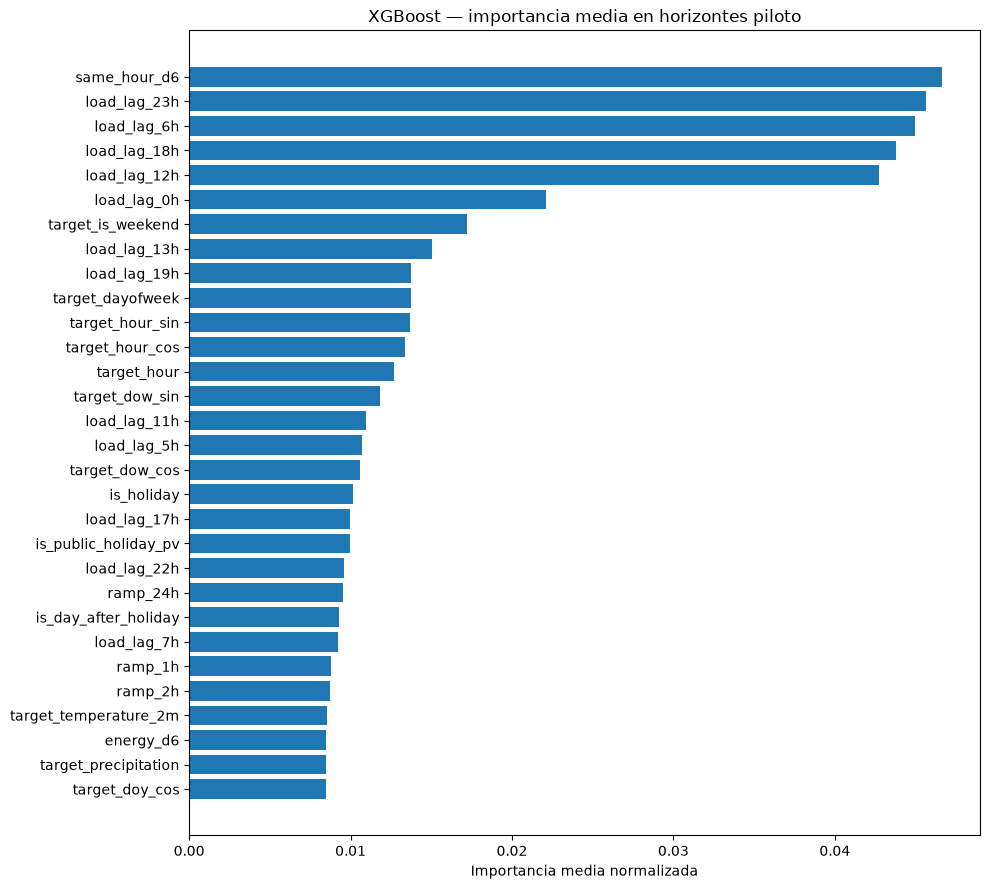

In [ ]:
# Visualizar las principales variables
top_imp = (
    importance_mean.head(30)
    .sort_values("importance_norm")
)

plt.figure(figsize=(10, 9))
plt.barh(
    top_imp["feature"],
    top_imp["importance_norm"],
)
plt.xlabel("Importancia media normalizada")
plt.title(
    f"{BEST_MODEL_NAME} — importancia media "
    "en horizontes piloto"
)
plt.tight_layout()
plt.show()

Comprobamos si la selección mejora validation:

In [20]:
selection_comparison = []

for feature_variant, feature_list in [
    ("base", ALL_FEATURE_COLUMNS),
    ("selected", SELECTED_FEATURES),
]:
    for h in PILOT_HORIZONS:
        d = make_horizon_dataset(
            features,
            weather,
            h,
        )

        train = get_train_rows(d)
        val = get_validation_rows(d)
        val = val.loc[
            valid_target_quality_mask(val)
        ]

        X_train = (
            train[feature_list]
            .replace([np.inf, -np.inf], np.nan)
            .astype("float32")
        )

        X_val = (
            val[feature_list]
            .replace([np.inf, -np.inf], np.nan)
            .astype("float32")
        )

        model = default_model(BEST_MODEL_NAME)

        model.fit(
            X_train,
            train["target"],
        )

        pred = clip_prediction(
            model.predict(X_val)
        )

        row = {
            "variant": feature_variant,
            "horizon": h,
        }

        row.update(
            regression_metrics(
                val["target"],
                pred,
            )
        )

        selection_comparison.append(row)

selection_comparison = pd.DataFrame(
    selection_comparison
)

display(
    selection_comparison
    .groupby("variant")[
        ["MAE", "RMSE", "WAPE_pct", "sMAPE_pct", "R2"]
    ]
    .mean()
)

variant_mean = (
    selection_comparison
    .groupby("variant")["WAPE_pct"]
    .mean()
)

BEST_FEATURE_VARIANT = variant_mean.idxmin()

FINAL_FEATURES = (
    SELECTED_FEATURES
    if BEST_FEATURE_VARIANT == "selected"
    else ALL_FEATURE_COLUMNS
)

print("Variante ganadora:", BEST_FEATURE_VARIANT)
print("Nº features finales:", len(FINAL_FEATURES))

,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
variant,,,,,
base,9.877445,13.24443,5.146143,5.235969,0.873987
selected,10.004781,13.38530,5.248542,5.343891,0.865615


Variante ganadora: base
Nº features finales: 104


Optimización de hiperparámetros con Optuna:

In [ ]:
def suggest_params(trial, model_name):
    if model_name == "LightGBM":
        return {
            "n_estimators": trial.suggest_int(
                "n_estimators", 300, 1400
            ),
            "learning_rate": trial.suggest_float(
                "learning_rate", 0.01, 0.10, log=True
            ),
            "num_leaves": trial.suggest_int(
                "num_leaves", 16, 128
            ),
            "max_depth": trial.suggest_int(
                "max_depth", 4, 14
            ),
            "min_child_samples": trial.suggest_int(
                "min_child_samples", 15, 150
            ),
            "subsample": trial.suggest_float(
                "subsample", 0.70, 1.0
            ),
            "colsample_bytree": trial.suggest_float(
                "colsample_bytree", 0.65, 1.0
            ),
            "reg_alpha": trial.suggest_float(
                "reg_alpha", 1e-6, 10.0, log=True
            ),
            "reg_lambda": trial.suggest_float(
                "reg_lambda", 1e-6, 20.0, log=True
            ),
        }

    if model_name == "XGBoost":
        return {
            "n_estimators": trial.suggest_int(
                "n_estimators", 300, 1400
            ),
            "learning_rate": trial.suggest_float(
                "learning_rate", 0.01, 0.10, log=True
            ),
            "max_depth": trial.suggest_int(
                "max_depth", 3, 10
            ),
            "min_child_weight": trial.suggest_float(
                "min_child_weight", 1, 20
            ),
            "subsample": trial.suggest_float(
                "subsample", 0.70, 1.0
            ),
            "colsample_bytree": trial.suggest_float(
                "colsample_bytree", 0.65, 1.0
            ),
            "reg_alpha": trial.suggest_float(
                "reg_alpha", 1e-6, 10.0, log=True
            ),
            "reg_lambda": trial.suggest_float(
                "reg_lambda", 1e-6, 20.0, log=True
            ),
        }

    if model_name == "CatBoost":
        return {
            "iterations": trial.suggest_int(
                "iterations", 300, 1400
            ),
            "learning_rate": trial.suggest_float(
                "learning_rate", 0.01, 0.10, log=True
            ),
            "depth": trial.suggest_int(
                "depth", 4, 10
            ),
            "l2_leaf_reg": trial.suggest_float(
                "l2_leaf_reg", 1e-3, 30.0, log=True
            ),
            "random_strength": trial.suggest_float(
                "random_strength", 0.0, 4.0
            ),
        }

    raise ValueError(model_name)


def model_with_params(model_name, params):
    model = default_model(model_name)
    model.set_params(**params)
    return model

In [ ]:
optuna_data = {}

for h in PILOT_HORIZONS:
    d = make_horizon_dataset(
        features,
        weather,
        h,
    )

    train = get_train_rows(d)
    val = get_validation_rows(d)

    val = val.loc[
        valid_target_quality_mask(val)
    ]

    optuna_data[h] = {
        "X_train": (
            train[FINAL_FEATURES]
            .replace([np.inf, -np.inf], np.nan)
            .astype("float32")
        ),
        "y_train": train["target"].astype("float32"),
        "X_val": (
            val[FINAL_FEATURES]
            .replace([np.inf, -np.inf], np.nan)
            .astype("float32")
        ),
        "y_val": val["target"].astype("float32"),
    }

In [23]:
def objective(trial):
    params = suggest_params(
        trial,
        BEST_MODEL_NAME,
    )

    wapes = []

    for h in PILOT_HORIZONS:
        data = optuna_data[h]

        model = model_with_params(
            BEST_MODEL_NAME,
            params,
        )

        model.fit(
            data["X_train"],
            data["y_train"],
        )

        pred = clip_prediction(
            model.predict(data["X_val"])
        )

        metrics = regression_metrics(
            data["y_val"],
            pred,
        )

        wapes.append(
            metrics["WAPE_pct"]
        )

    return float(np.mean(wapes))


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_SEED
    ),
)

study.optimize(
    objective,
    n_trials=N_OPTUNA_TRIALS,
    show_progress_bar=True,
)

print("Mejor WAPE medio validation:", study.best_value)
print("Mejores parámetros:")
print(study.best_params)

with open(
    ARTIFACTS_DIR / "optuna_best_params.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        study.best_params,
        f,
        indent=2,
    )

Best trial: 33. Best value: 5.02836: 100%|██████████| 40/40 [2:06:16<00:00, 189.42s/it]  

Mejor WAPE medio validation: 5.028356410082848
Mejores parámetros:
{'n_estimators': 1120, 'learning_rate': 0.03044952202127967, 'max_depth': 8, 'min_child_weight': 11.53667029799859, 'subsample': 0.7930008825905863, 'colsample_bytree': 0.855108010497067, 'reg_alpha': 1.4945483160808055, 'reg_lambda': 0.370817122691382}


Entrenar los 24 modelos finales:

In [24]:
FINAL_MODELS = {}

for h in range(1, FORECAST_HORIZON + 1):
    print(f"Entrenando modelo final h={h:02d}")

    d = make_horizon_dataset(
        features,
        weather,
        h,
    )

    trainval = get_final_train_rows(d)

    X = (
        trainval[FINAL_FEATURES]
        .replace([np.inf, -np.inf], np.nan)
        .astype("float32")
    )

    y = trainval["target"].astype("float32")

    model = model_with_params(
        BEST_MODEL_NAME,
        study.best_params,
    )

    model.fit(X, y)

    FINAL_MODELS[h] = model

    joblib.dump(
        model,
        ARTIFACTS_DIR / f"aggregate_h{h:02d}.pkl",
    )

joblib.dump(
    FINAL_FEATURES,
    ARTIFACTS_DIR / "final_features.pkl",
)

print("24 modelos agregados entrenados y guardados.")

Entrenando modelo final h=01
Entrenando modelo final h=02
Entrenando modelo final h=03
Entrenando modelo final h=04
Entrenando modelo final h=05
Entrenando modelo final h=06
Entrenando modelo final h=07
Entrenando modelo final h=08
Entrenando modelo final h=09
Entrenando modelo final h=10
Entrenando modelo final h=11
Entrenando modelo final h=12
Entrenando modelo final h=13
Entrenando modelo final h=14
Entrenando modelo final h=15
Entrenando modelo final h=16
Entrenando modelo final h=17
Entrenando modelo final h=18
Entrenando modelo final h=19
Entrenando modelo final h=20
Entrenando modelo final h=21
Entrenando modelo final h=22
Entrenando modelo final h=23
Entrenando modelo final h=24
24 modelos agregados entrenados y guardados.


In [ ]:
# Guardar configuración

def json_python_value(x):
    if isinstance(x, np.bool_):
        return bool(x)
    if isinstance(x, np.integer):
        return int(x)
    if isinstance(x, np.floating):
        return float(x)
    return x


config = {
    "problem": "Bilbao fixed energy-community aggregate demand",
    "community_users": int(len(COMMUNITY_USERS)),
    "community_start": str(COMMUNITY_START),
    "algorithm": str(BEST_MODEL_NAME),
    "feature_variant": str(BEST_FEATURE_VARIANT),
    "features": list(FINAL_FEATURES),
    "optuna_best_params": {
        k: json_python_value(v)
        for k, v in study.best_params.items()
    },
    "forecast_horizon": int(FORECAST_HORIZON),
    "forecast_origin_local_hour": int(FORECAST_ORIGIN_LOCAL_HOUR),
    "architecture": "24 direct horizon-specific aggregate models",
    "train_end": str(TRAIN_END),
    "validation_end": str(VAL_END),
    "test_end": str(TEST_END),
    "max_individual_imputed_pct": float(MAX_IMPUTED_PCT),
}

with open(
    ARTIFACTS_DIR / "final_config.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        config,
        f,
        indent=2,
        ensure_ascii=False,
    )

Evaluación final sobre test:

In [26]:
prediction_parts = []

for h in range(1, FORECAST_HORIZON + 1):
    d = make_horizon_dataset(
        features,
        weather,
        h,
    )

    test = get_test_rows(d)

    test = test.loc[
        valid_target_quality_mask(test)
    ].copy()

    X = (
        test[FINAL_FEATURES]
        .replace([np.inf, -np.inf], np.nan)
        .astype("float32")
    )

    test["prediction"] = clip_prediction(
        FINAL_MODELS[h].predict(X)
    )

    test["horizon"] = h

    prediction_parts.append(
        test[
            [
                "Fecha",
                "target_time_utc",
                "target_date_local",
                "horizon",
                "target",
                "prediction",
                "target_imputed_user_frac",
            ]
        ]
    )

test_predictions = pd.concat(
    prediction_parts,
    ignore_index=True,
)

test_predictions = test_predictions.sort_values(
    ["Fecha", "horizon"]
).reset_index(drop=True)

print(test_predictions.shape)
display(test_predictions.head(30))

(4345, 7)


,Fecha,target_time_utc,target_date_local,horizon,target,prediction,target_imputed_user_frac
0,2021-12-01 22:00:00,2021-12-01 23:00:00,2021-12-02,1,316.846008,338.040314,0.0
1,2021-12-01 22:00:00,2021-12-02 00:00:00,2021-12-02,2,245.688995,256.900116,0.0
2,2021-12-01 22:00:00,2021-12-02 01:00:00,2021-12-02,3,194.608002,183.676636,0.0
3,2021-12-01 22:00:00,2021-12-02 02:00:00,2021-12-02,4,142.955002,141.240433,0.0
4,2021-12-01 22:00:00,2021-12-02 03:00:00,2021-12-02,5,129.500000,123.646492,0.0
5,2021-12-01 22:00:00,2021-12-02 04:00:00,2021-12-02,6,122.660004,123.562149,0.0
6,2021-12-01 22:00:00,2021-12-02 05:00:00,2021-12-02,7,120.918999,117.694443,0.0
7,2021-12-01 22:00:00,2021-12-02 06:00:00,2021-12-02,8,120.067001,123.030495,0.0
8,2021-12-01 22:00:00,2021-12-02 07:00:00,2021-12-02,9,163.005997,170.670624,0.0
9,2021-12-01 22:00:00,2021-12-02 08:00:00,2021-12-02,10,249.882996,260.621918,0.0


Métricas finales globales y por horizonte:

In [27]:
overall_metrics = regression_metrics(
    test_predictions["target"],
    test_predictions["prediction"],
)

display(
    pd.DataFrame([overall_metrics])
)

horizon_rows = []

for h, part in test_predictions.groupby("horizon"):
    row = {"horizon": int(h)}
    row.update(
        regression_metrics(
            part["target"],
            part["prediction"],
        )
    )
    horizon_rows.append(row)

metrics_by_horizon = pd.DataFrame(
    horizon_rows
)

display(metrics_by_horizon)

pd.DataFrame([overall_metrics]).to_csv(
    ARTIFACTS_DIR / "test_metrics_overall.csv",
    index=False,
)

metrics_by_horizon.to_csv(
    ARTIFACTS_DIR / "test_metrics_by_horizon.csv",
    index=False,
)

,n,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
0,4345,11.184541,16.016642,5.741299,5.604038,0.947118


,horizon,n,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
0,1,182,10.006375,12.574370,3.636848,3.630759,0.911986
1,2,182,9.665099,12.265353,4.291175,4.277522,0.826407
2,3,181,7.845225,10.901457,4.445960,4.505069,0.722441
3,4,180,6.908703,10.177321,5.104651,5.016524,0.551189
4,5,181,5.422668,7.395086,4.721902,4.703685,0.665532
5,6,181,4.035777,5.186989,3.838933,3.868809,0.841069
6,7,181,4.375349,5.417200,4.393967,4.402004,0.854462
7,8,181,4.231629,5.383787,4.176116,4.167706,0.883533
8,9,181,5.804715,7.914461,4.839299,4.911375,0.940752
9,10,181,9.034475,12.724674,5.475698,5.884166,0.957226


Comparación final contra baselines:

In [ ]:
baseline_test_rows = []

# Reconstruir los baselines para las mismas filas/orígenes
for h in range(1, 25):
    d = make_horizon_dataset(
        features,
        weather,
        h,
    )

    test = get_test_rows(d)
    test = test.loc[
        valid_target_quality_mask(test)
    ]

    candidates = {
        "D-1": test["target_lag_24h"],

        "W-1": test["target_lag_168h"],

        "mean_D1_W1": (
            test["target_lag_24h"]
            + test["target_lag_168h"]
        ) / 2
    }

    for name, pred in candidates.items():
        tmp = pd.DataFrame(
            {
                "target": test["target"].to_numpy(),
                "prediction": np.asarray(pred),
                "model": name,
            }
        )

        baseline_test_rows.append(tmp)

baseline_long = pd.concat(
    baseline_test_rows,
    ignore_index=True,
)

comparison_rows = []

for name, part in baseline_long.groupby("model"):
    row = {"model": name}
    row.update(
        regression_metrics(
            part["target"],
            part["prediction"],
        )
    )
    comparison_rows.append(row)

final_row = {
    "model": f"{BEST_MODEL_NAME}_direct24_aggregate"
}
final_row.update(overall_metrics)
comparison_rows.append(final_row)

final_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("WAPE_pct")
)

display(final_comparison)

final_comparison.to_csv(
    ARTIFACTS_DIR / "test_comparison.csv",
    index=False,
)

,model,n,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
3,XGBoost_direct24_aggregate,4345,11.184541,16.016642,5.741299,5.604038,0.947118
2,mean_D1_W1,4345,15.998026,23.370233,8.212179,8.060237,0.887413
0,D-1,4345,17.851627,28.425983,9.163678,8.838973,0.833431
1,W-1,4345,21.036034,31.503879,10.798312,10.581217,0.795407


Energía total de las próximas 24 h:

In [29]:
daily_energy = (
    test_predictions
    .groupby("Fecha", as_index=False)
    .agg(
        actual_24h=("target", "sum"),
        predicted_24h=("prediction", "sum"),
        n_hours=("horizon", "count"),
    )
)

daily_energy = daily_energy.loc[
    daily_energy["n_hours"] == 24
]

daily_energy_metrics = regression_metrics(
    daily_energy["actual_24h"],
    daily_energy["predicted_24h"],
)

print("Métricas de energía CE 24 h:")
display(
    pd.DataFrame([daily_energy_metrics])
)

Métricas de energía CE 24 h:


,n,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
0,180,135.63967,188.997847,2.899222,2.925173,0.931576


Predicción del pico diario:

In [30]:
peak_rows = []

for origin, part in test_predictions.groupby("Fecha"):
    if len(part) != 24:
        continue

    part = part.sort_values("horizon")

    real_idx = part["target"].to_numpy().argmax()
    pred_idx = part["prediction"].to_numpy().argmax()

    peak_rows.append(
        {
            "Fecha": origin,
            "real_peak": float(
                part.iloc[real_idx]["target"]
            ),
            "pred_peak": float(
                part.iloc[pred_idx]["prediction"]
            ),
            "real_peak_horizon": int(
                part.iloc[real_idx]["horizon"]
            ),
            "pred_peak_horizon": int(
                part.iloc[pred_idx]["horizon"]
            ),
        }
    )

peak_df = pd.DataFrame(peak_rows)

peak_magnitude_metrics = regression_metrics(
    peak_df["real_peak"],
    peak_df["pred_peak"],
)

peak_df["peak_hour_abs_error"] = (
    peak_df["real_peak_horizon"]
    - peak_df["pred_peak_horizon"]
).abs()

print("Magnitud del pico:")
display(
    pd.DataFrame([peak_magnitude_metrics])
)

print(
    "Error absoluto medio de la hora del pico:",
    peak_df["peak_hour_abs_error"].mean(),
    "horas",
)

Magnitud del pico:


,n,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
0,180,18.028537,23.139846,5.776089,5.821822,0.832476


Error absoluto medio de la hora del pico: 3.138888888888889 horas


Gráfico de las métricas finales:

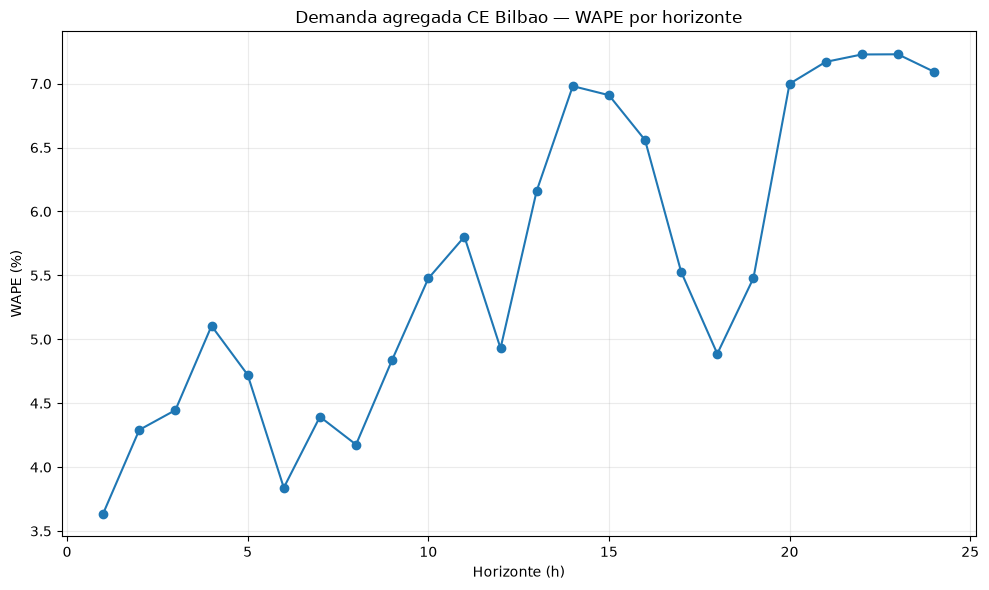

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(
    metrics_by_horizon["horizon"],
    metrics_by_horizon["WAPE_pct"],
    marker="o",
)
plt.xlabel("Horizonte (h)")
plt.ylabel("WAPE (%)")
plt.title(
    "Demanda agregada CE Bilbao — WAPE por horizonte"
)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Gráficos del consumo real vs estimado para algunas semanas del conjunto test:

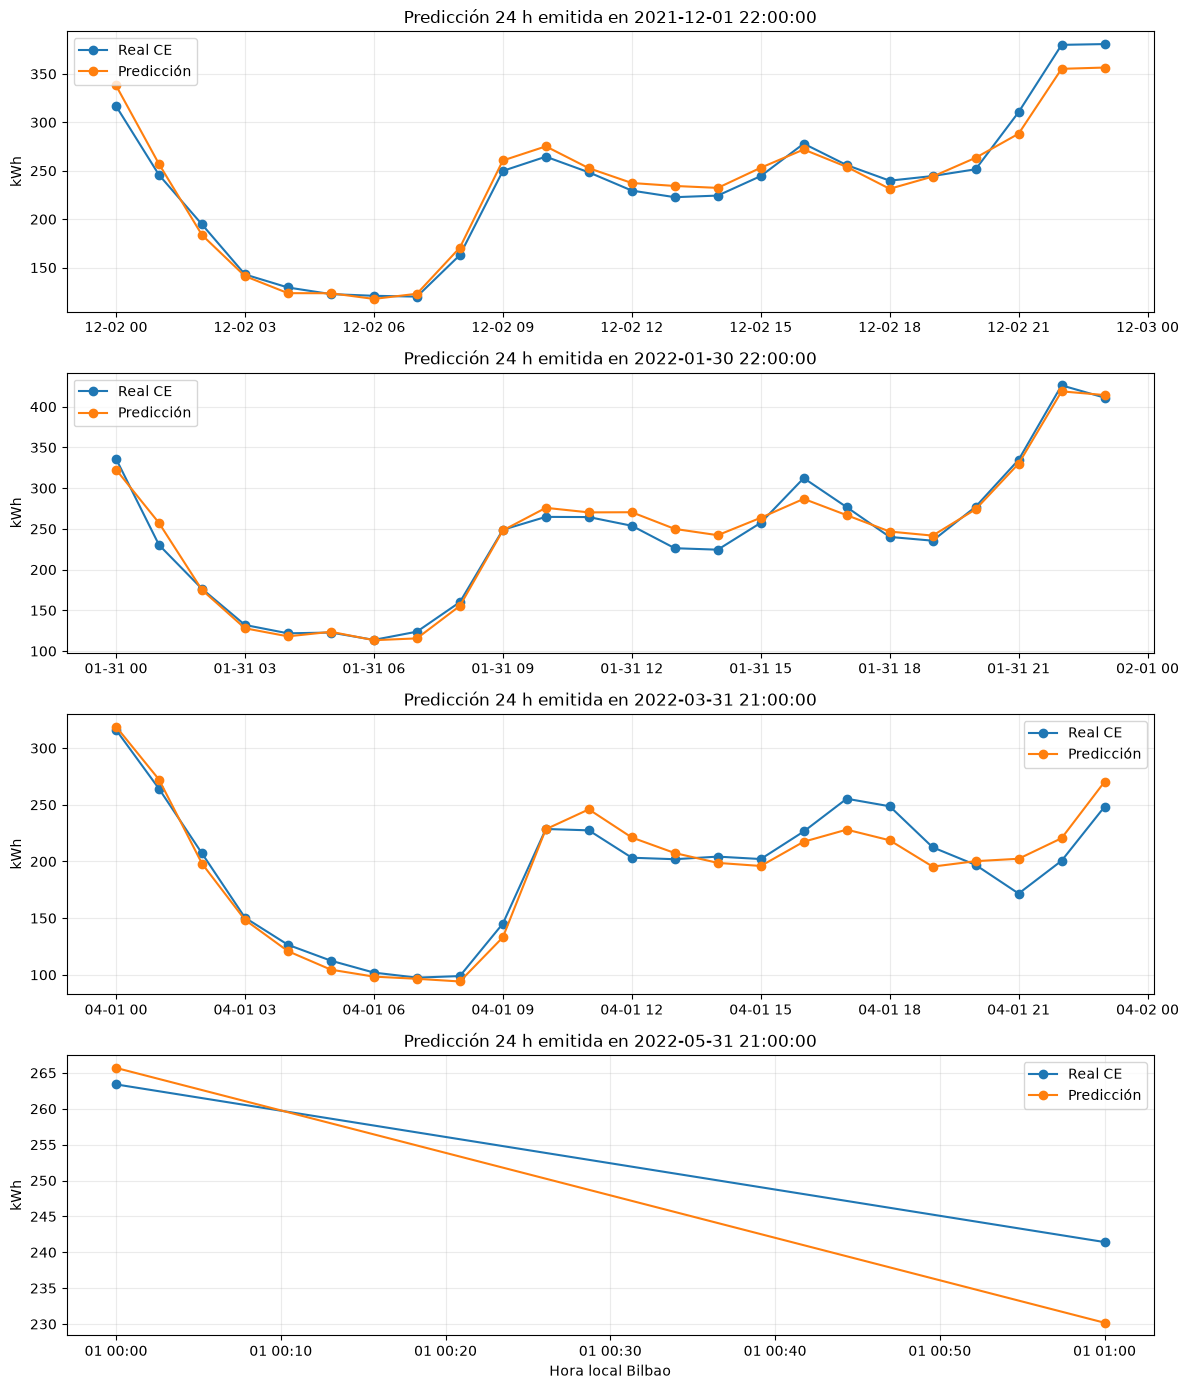

In [ ]:
origins = (
    test_predictions["Fecha"]
    .drop_duplicates()
    .sort_values()
)

n_examples = min(4, len(origins))

positions = np.linspace(
    0,
    len(origins) - 1,
    n_examples,
    dtype=int,
)

chosen_origins = origins.iloc[positions]

fig, axes = plt.subplots(
    n_examples,
    1,
    figsize=(12, 3.5 * n_examples),
    squeeze=False,
)

for ax, origin in zip(
    axes.ravel(),
    chosen_origins,
):
    part = (
        test_predictions.loc[
            test_predictions["Fecha"] == origin
        ]
        .sort_values("horizon")
    )

    local_target = (
        pd.DatetimeIndex(
            part["target_time_utc"]
        )
        .tz_localize("UTC")
        .tz_convert(LOCAL_TIMEZONE)
        .tz_localize(None)
    )

    ax.plot(
        local_target,
        part["target"],
        marker="o",
        label="Real CE",
    )

    ax.plot(
        local_target,
        part["prediction"],
        marker="o",
        label="Predicción",
    )

    ax.set_ylabel("kWh")
    ax.set_title(
        f"Predicción 24 h emitida en {origin}"
    )
    ax.grid(alpha=.25)
    ax.legend()

axes.ravel()[-1].set_xlabel(
    "Hora local Bilbao"
)

fig.tight_layout()
plt.show()

Energía diaria real vs predicha:

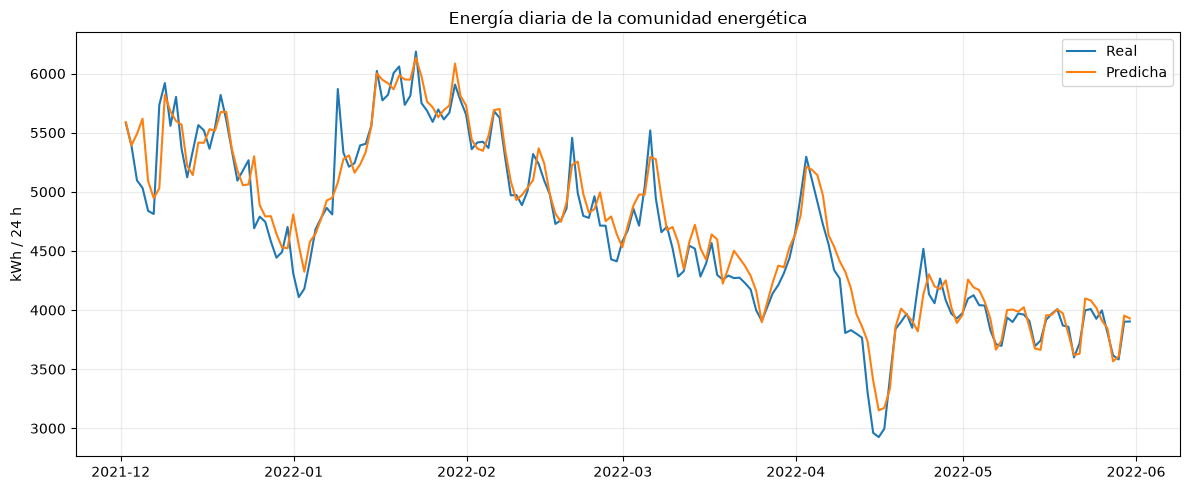

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_energy["Fecha"],
    daily_energy["actual_24h"],
    label="Real",
)

plt.plot(
    daily_energy["Fecha"],
    daily_energy["predicted_24h"],
    label="Predicha",
)

plt.ylabel("kWh / 24 h")
plt.title(
    "Energía diaria de la comunidad energética"
)
plt.legend()
plt.grid(alpha=.25)
plt.tight_layout()
plt.show()

Importancia del modelo final:

,feature,importance_norm
96,target_hour_sin,0.019858
39,load_lag_3h,0.017242
97,target_is_weekend,0.016962
26,load_lag_13h,0.016385
31,load_lag_18h,0.015986
32,load_lag_19h,0.015919
24,load_lag_11h,0.015772
45,load_lag_9h,0.015723
44,load_lag_8h,0.015722
77,same_hour_d6,0.015658


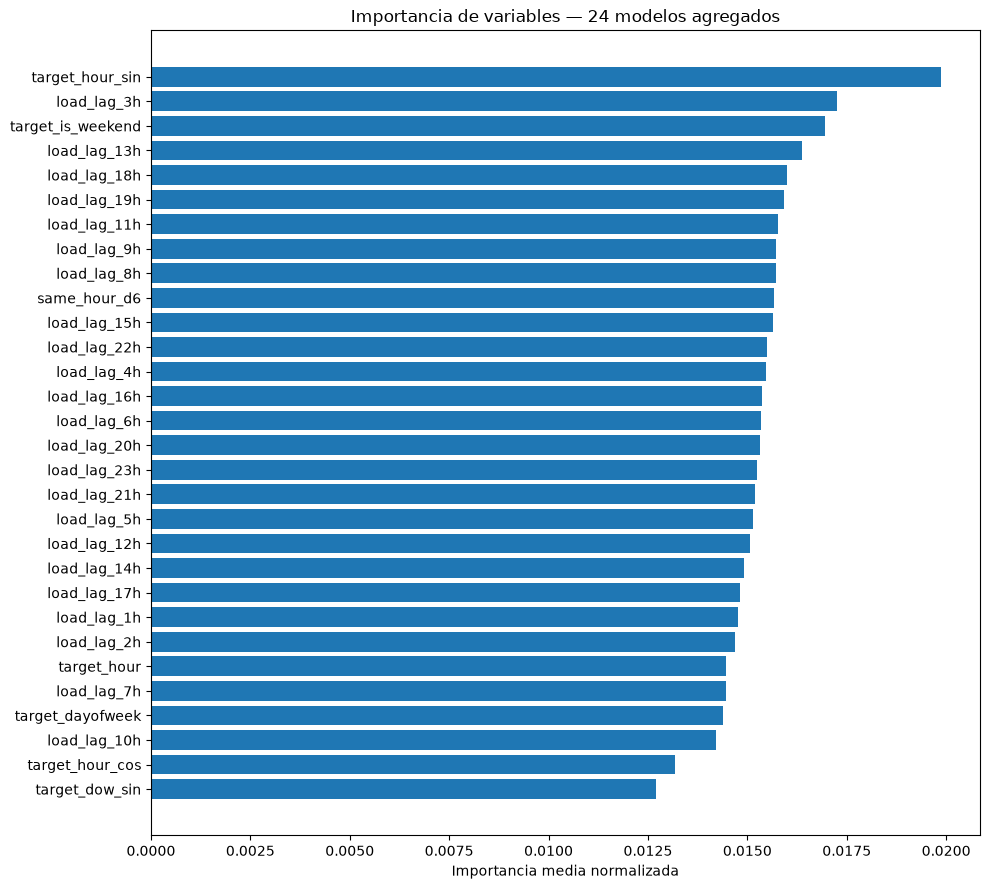

In [34]:
final_importance_parts = []

for h, model in FINAL_MODELS.items():
    imp = feature_importance_dataframe(
        BEST_MODEL_NAME,
        model,
        FINAL_FEATURES,
    )

    imp["horizon"] = h
    final_importance_parts.append(imp)

final_importance = pd.concat(
    final_importance_parts,
    ignore_index=True,
)

final_importance_mean = (
    final_importance
    .groupby("feature", as_index=False)["importance_norm"]
    .mean()
    .sort_values("importance_norm", ascending=False)
)

display(
    final_importance_mean.head(30)
)

top = (
    final_importance_mean.head(30)
    .sort_values("importance_norm")
)

plt.figure(figsize=(10, 9))
plt.barh(
    top["feature"],
    top["importance_norm"],
)
plt.xlabel("Importancia media normalizada")
plt.title(
    "Importancia de variables — 24 modelos agregados"
)
plt.tight_layout()
plt.show()

final_importance_mean.to_csv(
    ARTIFACTS_DIR / "final_feature_importance.csv",
    index=False,
)

Diagnóstico por hora local:

,hour,n,MAE,RMSE,WAPE_pct,sMAPE_pct,R2
0,0,183,10.153746,12.834392,3.686969,3.677462,0.908419
1,1,182,9.665099,12.265353,4.291175,4.277522,0.826407
2,2,180,7.857074,10.923402,4.446044,4.506045,0.714553
3,3,181,6.902094,10.158046,5.101069,5.012727,0.550823
4,4,180,5.412320,7.395692,4.709973,4.688680,0.665460
5,5,181,4.035659,5.186822,3.837379,3.865467,0.840581
6,6,181,4.384283,5.427906,4.401820,4.410310,0.853628
7,7,181,4.256104,5.399559,4.198631,4.195343,0.882302
8,8,181,5.762192,7.886969,4.802674,4.859564,0.941034
9,9,181,8.950544,12.615025,5.427405,5.816104,0.958099


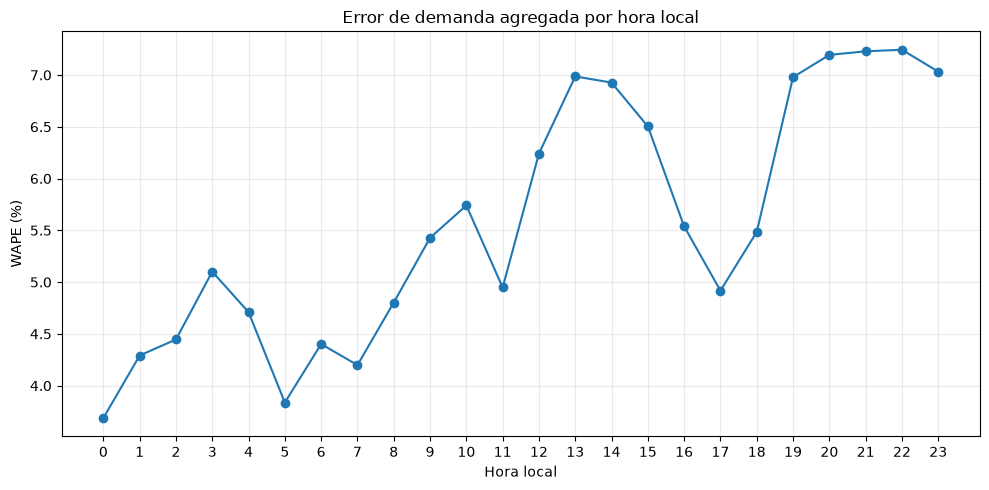

In [35]:
tmp = test_predictions.copy()

target_local = (
    pd.DatetimeIndex(tmp["target_time_utc"])
    .tz_localize("UTC")
    .tz_convert(LOCAL_TIMEZONE)
)

tmp["target_hour_local"] = np.asarray(
    target_local.hour
)

hour_rows = []

for hour, part in tmp.groupby("target_hour_local"):
    row = {"hour": int(hour)}
    row.update(
        regression_metrics(
            part["target"],
            part["prediction"],
        )
    )
    hour_rows.append(row)

metrics_by_hour = pd.DataFrame(hour_rows)

display(metrics_by_hour)

plt.figure(figsize=(10, 5))
plt.plot(
    metrics_by_hour["hour"],
    metrics_by_hour["WAPE_pct"],
    marker="o",
)
plt.xlabel("Hora local")
plt.ylabel("WAPE (%)")
plt.title("Error de demanda agregada por hora local")
plt.xticks(range(24))
plt.grid(alpha=.25)
plt.tight_layout()
plt.show()